# 01 — METABRIC Dataset Exploration

**Dataset**: Breast Cancer Gene Expression Profiles (METABRIC)  
**Source**: Kaggle - raghadalharbi/breast-cancer-gene-expression-profiles-metabric  
**Patients**: 1,904 | **Variables**: 693

---

## Research Questions

1. **Survival analysis**: Which clinical and genomic factors are associated with the overall survival of breast cancer patients?
2. **ML**: Can we predict 5-year survival based on clinical and genomic characteristics?

## Key Variables

| Type | Variables |
|---|---|
| **Target** | `overall_survival_months`, `overall_survival` (censoring) |
| **Clinical** | `age_at_diagnosis`, `tumor_size`, `nottingham_prognostic_index`, `lymph_nodes_examined_positive` |
| **Biomarkers** | `er_status`, `her2_status`, `pr_status` |
| **Treatments** | `chemotherapy`, `hormone_therapy`, `radio_therapy` |
| **Genomic** | `mutation_count` + gene expression columns + mutations (_mut) |

---

## Notebook Outline

0. Setup & Loading  
1. General Overview  
2. Target Variable  
3. Outliers  
4. Missing Values  
5. Key Variables Distributions  
6. Summary & Decisions for Preprocessing

## 0. Setup & Loading

Loading libraries and the CSV file. The parameter `low_memory=False` is necessary because some mutation columns have mixed types (integers and strings).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import os

DATA_PATH = r"../data/METABRIC_RNA_Mutation.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"✅ {df.shape[0]} patients, {df.shape[1]} variables")

✅ 1904 patients, 693 variables


## 1. General Overview

We start with the three standard tools of any EDA:
- `head()` to visually check that the data makes sense
- `info()` to know the actual types and the number of non-null values per column
- `describe()` to detect obvious outliers (abnormal min/max)

In [2]:
display(df.head())

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0


> We observe that the dataset mixes readable clinical variables (age, ER status, treatments) with gene expression columns whose names are gene symbols (e.g., `ERBB2`, `ESR1`). Expression values are continuous decimals.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1904 entries, 0 to 1903
Columns: 693 entries, patient_id to siah1_mut
dtypes: float64(498), int64(5), object(190)
memory usage: 10.1+ MB


> `info()` confirms the presence of `object` columns (categorical variables: ER/PR/HER2 statuses, treatments) and `float64` columns (continuous variables: age, NPI, gene expression). Non-null counts below 1904 already indicate missing values: we will quantify them in section 4.

In [4]:
display(df.describe().iloc[:, :15].T.round(2))

,count,mean,std,min,25%,50%,75%,max
patient_id,1904.0,3921.98,2358.48,0.00,896.50,4730.50,5536.25,7299.00
age_at_diagnosis,1904.0,61.09,12.98,21.93,51.38,61.77,70.59,96.29
chemotherapy,1904.0,0.21,0.41,0.00,0.00,0.00,0.00,1.00
cohort,1904.0,2.64,1.23,1.00,1.00,3.00,3.00,5.00
neoplasm_histologic_grade,1832.0,2.42,0.65,1.00,2.00,3.00,3.00,3.00
hormone_therapy,1904.0,0.62,0.49,0.00,0.00,1.00,1.00,1.00
lymph_nodes_examined_positive,1904.0,2.00,4.08,0.00,0.00,0.00,2.00,45.00
mutation_count,1859.0,5.70,4.06,1.00,3.00,5.00,7.00,80.00
nottingham_prognostic_index,1904.0,4.03,1.14,1.00,3.05,4.04,5.04,6.36
overall_survival_months,1904.0,125.12,76.33,0.00,60.83,115.62,184.72,355.20


> `describe()` covers only numerical columns. We can already note:
> - `age_at_diagnosis`: min=21.9, max=96.3 → clinically coherent range
> - `tumor_size`: max=182mm → suspicious, needs investigation
> - `mutation_count`: max=80 → highly skewed distribution, needs confirmation
> - `overall_survival_months`: max=355 months (~29 years) → cohort with very long follow-up

In [5]:
print("="*20 + "\n Available Columns\n" + "="*20)
for col in df.columns[:31]:
    print(f"{col}")
    

 Available Columns
patient_id
age_at_diagnosis
type_of_breast_surgery
cancer_type
cancer_type_detailed
cellularity
chemotherapy
pam50_+_claudin-low_subtype
cohort
er_status_measured_by_ihc
er_status
neoplasm_histologic_grade
her2_status_measured_by_snp6
her2_status
tumor_other_histologic_subtype
hormone_therapy
inferred_menopausal_state
integrative_cluster
primary_tumor_laterality
lymph_nodes_examined_positive
mutation_count
nottingham_prognostic_index
oncotree_code
overall_survival_months
overall_survival
pr_status
radio_therapy
3-gene_classifier_subtype
tumor_size
tumor_stage
death_from_cancer


### Variable Blocks Separation

The dataset contains 5 types of variables with very different properties. We separate them now to be able to process them independently during preprocessing.

The logic: we assign the explicitly known blocks (target, treatments, biomarkers, mutations). `clinical_cols` recovers everything else. A final check ensures no column is forgotten.

In [6]:
print("="*30 + "\n Variable Blocks Separation\n" + "="*30)

target_cols    = ["overall_survival", "overall_survival_months"]
treatment_cols = ["chemotherapy", "hormone_therapy", "radio_therapy"]
biomarker_cols = ["er_status", "pr_status", "her2_status",
                  "er_status_measured_by_ihc", "her2_status_measured_by_snp6"]
clinical_cols  = [
    "age_at_diagnosis", "type_of_breast_surgery", "cancer_type",
    "cancer_type_detailed", "cellularity", "cohort", "neoplasm_histologic_grade",
    "tumor_other_histologic_subtype", "inferred_menopausal_state",
    "integrative_cluster", "primary_tumor_laterality", "lymph_nodes_examined_positive",
    "mutation_count", "nottingham_prognostic_index", "oncotree_code",
    "pam50_+_claudin-low_subtype", "3-gene_classifier_subtype", "tumor_size",
    "tumor_stage", "death_from_cancer" 
]
mut_cols       = [c for c in df.columns if c.endswith("_mut")]
already_assigned = target_cols + treatment_cols + biomarker_cols + mut_cols + clinical_cols + ["patient_id"]

expr_cols      = [c for c in df.columns if c not in already_assigned]

column_groups = {
    "🎯 Target": target_cols,
    "💊 Treatments": treatment_cols,
    "🔬 Biomarkers": biomarker_cols,
    "👩‍⚕️ Clinical": clinical_cols,
    "🧬 Expression": expr_cols,
    "⚠️ Mutations": mut_cols
}

print(f"🎯 Target       : {len(target_cols)}")
print(f"💊 Treatments   : {len(treatment_cols)}")
print(f"🔬 Biomarkers   : {len(biomarker_cols)}")
print(f"👩‍⚕️ Clinical     : {len(clinical_cols)}")
print(f"🧬 Expression   : {len(expr_cols)}")
print(f"⚠️ Mutations    : {len(mut_cols)}")

total = len(target_cols)+len(treatment_cols)+len(biomarker_cols)+len(clinical_cols)+len(expr_cols)+len(mut_cols)+1
print(f"\nTotal assigned : {total} / {df.shape[1]} {'✅' if total == df.shape[1] else '⚠️'}")

 Variable Blocks Separation
🎯 Target       : 2
💊 Treatments   : 3
🔬 Biomarkers   : 5
👩‍⚕️ Clinical     : 20
🧬 Expression   : 489
⚠️ Mutations    : 173

Total assigned : 693 / 693 ✅


In [7]:
print("="*40 + "\n📊 SUMMARY OF GROUPS (TYPE + Examples)\n" + "="*40)

for group_name, col_list in column_groups.items():
    # Security: verify that the columns are still present in the df
    present_cols = [c for c in col_list if c in df.columns]

    # Display the group name and the count
    print(f"\n{group_name} : {len(present_cols)}")
    print("-"*40)

    if len(present_cols) == 0:
        continue

    # Display each column with its type and a sample of unique values
    check = pd.DataFrame({
        "Type": df[present_cols].dtypes.astype(str),
        # Fetch up to 5 unique values, ignoring NaNs for a cleaner display
        "Examples": [
            df[c].dropna().unique()[:5] for c in present_cols
        ]
    })

    display(check)

📊 SUMMARY OF GROUPS (TYPE + Examples)

🎯 Target : 2
----------------------------------------


,Type,Examples
overall_survival,int64,"[1, 0]"
overall_survival_months,float64,"[140.5, 84.63333333, 163.7, 164.93333330000002..."



💊 Treatments : 3
----------------------------------------


,Type,Examples
chemotherapy,int64,"[0, 1]"
hormone_therapy,int64,"[1, 0]"
radio_therapy,int64,"[1, 0]"



🔬 Biomarkers : 5
----------------------------------------


...

,Type,Examples
age_at_diagnosis,float64,"[75.65, 43.19, 48.87, 47.68, 76.97]"
type_of_breast_surgery,object,"[MASTECTOMY, BREAST CONSERVING]"
cancer_type,object,"[Breast Cancer, Breast Sarcoma]"
cancer_type_detailed,object,"[Breast Invasive Ductal Carcinoma, Breast Mixe..."
cellularity,object,"[High, Moderate, Low]"
cohort,float64,"[1.0, 2.0, 3.0, 5.0, 4.0]"
neoplasm_histologic_grade,float64,"[3.0, 2.0, 1.0]"
tumor_other_histologic_subtype,object,"[Ductal/NST, Mixed, Lobular, Tubular/ cribrifo..."
inferred_menopausal_state,object,"[Post, Pre]"
integrative_cluster,object,"[4ER+, 3, 9, 7, 4ER-]"



🧬 Expression : 489
----------------------------------------


,Type,Examples
brca1,float64,"[-1.399, -1.38, 0.067, 0.6744, 1.2932]"
brca2,float64,"[-0.5738, 0.2777, -0.8426, -0.5428, -0.9039]"
palb2,float64,"[-1.6217, -1.2154, 0.2114, -1.6592, -0.7219]"
pten,float64,"[1.4524, 0.5296, -0.3326, 0.6369, 0.2168]"
tp53,float64,"[0.3504, -0.0136, 0.5141, 1.6708, 0.3484]"
...,...,...
tnk2,float64,"[-1.1741, 0.9121, -3.7172, -2.3286, -0.1572]"
tulp4,float64,"[-1.4779, -0.9538, -1.5538, -0.9924, 0.0427]"
ugt2b15,float64,"[-0.5954, -0.2264, 1.3701, -0.3154, 5.0048]"
ugt2b17,float64,"[-0.8847, 0.5398, -0.1078, 0.2319999999999999,..."



⚠️ Mutations : 173
----------------------------------------


,Type,Examples
pik3ca_mut,object,"[0, H1047R, E542K, Q546H G1049R, E545K]"
tp53_mut,object,"[0, H178P, S241F, P67Qfs*56, C242R]"
muc16_mut,object,"[0, R5550S, P6040R, E2017V, E3861*]"
ahnak2_mut,object,"[0, E5575K, E1183*, V2061L, I5553T]"
kmt2c_mut,object,"[0, M1974Ifs*32, K1777Lfs*21, S3531Cfs*34, V12..."
...,...,...
hras_mut,object,"[0, Q61R, N86T]"
prps2_mut,object,"[0, G255R, I159F]"
smarcb1_mut,object,"[0, D159N, I28L]"
stmn2_mut,object,"[0, N145K, R156H]"


> The dataset contains **489 gene expression columns** and **173 mutation columns**, meaning 663 genomic variables out of 693 total. Feature selection will be essential before training an ML model.

## 2. Target Variable

### METABRIC Encoding

Before any analysis, we must understand how the survival variable is encoded. In the standard convention (lifelines, scikit-survival), `1 = event (death)` and `0 = censoring (alive)`. 

METABRIC uses the **reverse** convention: we verify it empirically: if `overall_survival=0` corresponds to deaths, these patients should have a **shorter** average follow-up.

In [34]:
print("="*20 + "\n METABRIC Encoding \n" + "="*20)

display(df.groupby("overall_survival")["overall_survival_months"].describe().round(1))

 METABRIC Encoding 


,count,mean,std,min,25%,50%,75%,max
overall_survival,,,,,,,,
0,1103.0,100.1,69.6,0.1,42.7,85.9,145.4,355.2
1,801.0,159.6,71.7,0.0,108.1,158.0,216.7,337.0


> ✅ **Encoding Confirmed**:
> - `overall_survival = 0` → death: median follow-up **85.9 months**
> - `overall_survival = 1` → alive: median follow-up **158.0 months**
>
> The deceased patients do indeed have a shorter follow-up, which is biologically coherent.
>
> ⚠️ **To remember for the next steps**: in the KM and Cox notebooks, we will systematically create:
> ```python
> df["event"] = 1 - df["overall_survival"]  # 1=death, 0=censored
> ```

### Distribution and Censoring Rate

The censoring rate is a key indicator of cohort quality for survival analysis. A censoring rate that is too high (> 80%) makes KM curves unreliable. A low rate means we observe many events, ideal for Cox models.

In [9]:
print("="*40 + "\n📊 Distribution and Censoring Rate\n" + "="*40)

n_deces    = (df["overall_survival"] == 0).sum()
n_vivantes = (df["overall_survival"] == 1).sum()
n_total    = len(df)

print(f"Observed deaths      : {n_deces} / {n_total} ({n_deces/n_total*100:.1f}%)")
print(f"Alive (censored)     : {n_vivantes} ({n_vivantes/n_total*100:.1f}%)")
print(f"\nMedian follow-up : {df['overall_survival_months'].median():.1f} months (~{df['overall_survival_months'].median()/12:.1f} years)")
print(f"Max follow-up    : {df['overall_survival_months'].max():.1f} months (~{df['overall_survival_months'].max()/12:.1f} years)")

📊 Distribution and Censoring Rate
Observed deaths      : 1103 / 1904 (57.9%)
Alive (censored)     : 801 (42.1%)

Median follow-up : 115.6 months (~9.6 years)
Max follow-up    : 355.2 months (~29.6 years)


> **Interpretation**:
> - **57.9% observed deaths** → high event rate, no excessive censoring issues
> - **Median follow-up ~9.6 years, max ~29.6 years** → highly mature cohort, ideal for KM curves
> - **Classes almost balanced (58/42)** → for ML, `class_weight='balanced'` will be useful but not critical
> - Comparison: a typical oncology clinical trial has 40-60% events at maturity → METABRIC falls right into this range ✅

## 3. Outliers

We inspect the key numerical variables with thresholds adapted to each variable:
- **Fixed clinical thresholds** for age and follow-up duration (biologically impossible values)
- **Empirical clinical threshold** for tumor size (> 150mm = extreme cases)
- **Statistical rule 3×IQR** for `mutation_count` because the distribution is highly skewed: a fixed threshold wouldn't make sense

In [36]:
print("="*20 + "\n OUTLIERS Analysis \n" + "="*20)

def summarize_variable(df, col, variable_name,
                       outlier_mask=None,
                       threshold=None):

    q1 = df[col].quantile(0.25)
    median = df[col].median()
    q3 = df[col].quantile(0.75)

    if outlier_mask is not None:
        n_out = outlier_mask.sum()
        pct = 100 * outlier_mask.mean()

        if threshold is not None:
            outlier_text = f"{n_out} ({pct:.1f}%) > {threshold}"
        else:
            outlier_text = f"{n_out} ({pct:.1f}%)"
    else:
        outlier_text = "-"

    return {
        "Variable": variable_name,
        "N": df[col].count(),
        "Mean ± SD": f"{df[col].mean():.2f} ± {df[col].std():.2f}",
        "Median (IQR)": f"{median:.2f} ({q1:.2f} - {q3:.2f})",
        "Range": f"{df[col].min():.1f} - {df[col].max():.1f}",
        "Outliers": outlier_text
    }

q1 = df["mutation_count"].quantile(0.25)
q3 = df["mutation_count"].quantile(0.75)
iqr = q3 - q1
threshold = q3 + 3 * iqr

summary = pd.DataFrame([

    summarize_variable(
        df,
        "age_at_diagnosis",
        "Age at diagnosis",
        (df["age_at_diagnosis"] < 18) |
        (df["age_at_diagnosis"] > 100),
        "18 - 100 years"
    ),

    summarize_variable(
        df,
        "overall_survival_months",
        "Follow-up duration (months)",
        df["overall_survival_months"] < 0,
        "0 months"
    ),

    summarize_variable(
        df,
        "tumor_size",
        "Tumor size (mm)",
        df["tumor_size"] > 150,
        "150 mm"
    ),

    summarize_variable(
        df,
        "mutation_count",
        "Number of mutations",
        df["mutation_count"] > threshold,
        f"{threshold:.1f}"
    )

])

display(summary)

 OUTLIERS Analysis 


,Variable,N,Mean ± SD,Median (IQR),Range,Outliers
0,Age at diagnosis,1904,61.09 ± 12.98,61.77 (51.38 - 70.59),21.9 - 96.3,0 (0.0%) > 18 - 100 years
1,Follow-up duration (months),1904,125.12 ± 76.33,115.62 (60.83 - 184.72),0.0 - 355.2,0 (0.0%) > 0 months
2,Tumor size (mm),1884,26.24 ± 15.16,23.00 (17.00 - 30.00),1.0 - 182.0,3 (0.2%) > 150 mm
3,Number of mutations,1859,5.70 ± 4.06,5.00 (3.00 - 7.00),1.0 - 80.0,18 (0.9%) > 19.0


> - **Age**: no outliers: range 21.9–96.3 years, coherent with an adult cohort
> - **Follow-up duration**: no negative values
> - **Tumor size**: 3 values > 150mm: needs investigation (large tumor is biologically possible, but rare)
> - **Mutation count**: 18 values > 19 mutations (3×IQR threshold), max=80: needs investigation

### Checking Clinical Consistency of Tumors > 150mm

A tumor larger than 150mm is biologically possible (locally advanced tumor) but exceptional. 

We cross-reference with stage and NPI to check if these values are coherent or if they are data entry errors.

In [39]:
print("="*50 + "\n Checking Clinical Consistency of Tumors > 150mm \n" + "="*50)

display(df[df["tumor_size"] > 150][["tumor_size", "tumor_stage",
                                     "nottingham_prognostic_index",
                                     "overall_survival_months",
                                     "overall_survival"]])

 Checking Clinical Consistency of Tumors > 150mm 


,tumor_size,tumor_stage,nottingham_prognostic_index,overall_survival_months,overall_survival
266,180.0,3.0,6.360,96.900000,0
460,160.0,1.0,6.320,18.933333,0
1812,182.0,NaN,5.364,147.166667,1


> **Case-by-case analysis**:
> - **Patient 266**: tumor_size=180mm, stage=3, NPI=6.36, death at 97 months → **coherent**: large tumor + advanced stage + high NPI. Keep.
> - **Patient 460**: tumor_size=160mm, stage=1, NPI=6.32, death at 19 months → **suspicious**: stage 1 implies a tumor ≤ 20mm with no positive lymph nodes. Contradicts size and NPI. Probable data entry error for stage. Early death at 19 months aligns with the high NPI → keep `tumor_size`, note the inconsistency.
> - **Patient 1812**: tumor_size=182mm, stage=NaN, NPI=5.36, alive at 147 months → **impossible to definitively conclude**: missing stage, unusual long survival for a tumor of this size. Flag to monitor.
>
> **Decision**: keep all 3 values. The count (3/1904) is too low to significantly impact models. A log-transform on `tumor_size` will reduce their influence anyway.
>
> **`mutation_count` max=80**: hypermutator profile is biologically plausible (MMR deficiency, BRCA2 mutation). These are not data entry errors. Strategy: **log1p transform** in preprocessing.

## 4. Missing Values

We analyze missing values on clinical columns only. Genomic columns (expression, mutations) have no missing data in METABRIC.

The key question is to distinguish the missing data mechanisms:
- **MCAR** (Missing Completely At Random): missingness independent of everything → imputation possible
- **MAR** (Missing At Random): missingness linked to other observed variables → imputation possible with caution
- **MNAR** (Missing Not At Random): missingness linked to the variable itself or the outcome → biased imputation, exclude

In [43]:
print("="*20 + "\n Missing Values \n" + "="*20)

missing = df[clinical_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({
    "n_missing": missing,
    "pct_missing": missing_pct
}).query("n_missing > 0").sort_values("pct_missing", ascending=False)

display(missing_df)

 Missing Values 


,n_missing,pct_missing
tumor_stage,501,26.3
3-gene_classifier_subtype,204,10.7
primary_tumor_laterality,106,5.6
neoplasm_histologic_grade,72,3.8
cellularity,54,2.8
mutation_count,45,2.4
type_of_breast_surgery,22,1.2
tumor_size,20,1.1
cancer_type_detailed,15,0.8
tumor_other_histologic_subtype,15,0.8


> `tumor_stage` clearly stands out with 26.3% missing, a rate too high for reliable imputation. We test below if this missingness is MNAR.

### MNAR Test for tumor_stage

If `tumor_stage` is MNAR, the missing rate will be significantly different between deceased and alive patients. Such a link with the outcome makes any imputation invalid.

In [48]:
for group in ["overall_survival"]:
    print("=" * 50 + "\n### tumor_stage missing rate by survival status : \n" + "=" * 50)
    
    mnar_table = (
        df.groupby(group)["tumor_stage"]
        .apply(lambda x: x.isnull().mean() * 100)
        .reset_index(name="Missing (%)")
                 )
    mnar_table["Missing (%)"] = mnar_table["Missing (%)"].round(2)

    display(mnar_table)


### tumor_stage missing rate by survival status : 


,overall_survival,Missing (%)
0,0,28.20
1,1,23.72


> - Deceased (`overall_survival=0`): **28.2%** missing
> - Alive (`overall_survival=1`): **23.7%** missing
> - 4.5 point difference → **MNAR confirmed**: the stage is missing more often in deceased patients, likely because more severe or older cases had less comprehensive staging.
> - Consequence: imputing `tumor_stage` would introduce a systematic bias linked to the outcome → **exclude from models**.

### NPI as a Proxy for tumor_stage

The Nottingham Prognostic Index (NPI) is calculated from tumor size, histological grade, and the number of positive lymph nodes. It should correlate with stage and could replace it in the models.

In [55]:
print("=" * 35 + "\n📊 NPI / tumor_stage correlation \n" + "=" * 35)

corr = df[["nottingham_prognostic_index", "tumor_stage"]].corr().round(2)
display(corr)

print("=" * 30 + "\n📊 Average NPI by tumor stage")
print("=" * 30)

npi_by_stage = (
    df.groupby("tumor_stage")["nottingham_prognostic_index"]
    .mean()
    .round(2)
    .reset_index(name="Average NPI")
)

display(npi_by_stage)


📊 NPI / tumor_stage correlation 


,nottingham_prognostic_index,tumor_stage
nottingham_prognostic_index,1.00,0.55
tumor_stage,0.55,1.00


📊 Average NPI by tumor stage


,tumor_stage,Average NPI
0,0.0,1.81
1,1.0,3.25
2,2.0,4.33
3,3.0,5.29
4,4.0,4.74


> - **Correlation r=0.55** → moderate correlation, expected (NPI and stage measure similar but not identical dimensions)
> - **Coherent clinical gradient**: NPI 1.8 (stage 0) → 5.3 (stage 3) → NPI increases properly with severity
> - The slight drop at stage 4 (NPI=4.7) is explained by the very small sample size (n=9)
> - **Conclusion**: NPI is a valid proxy for tumor_stage, and even richer because it integrates size + grade + lymph nodes into a continuous value.

### Missing Values Strategy

| Variable | % missing | Mechanism | Strategy |
|---|---|---|---|
| `tumor_stage` | 26.3% | MNAR | **Exclude from models** → use NPI as proxy |
| `3-gene_classifier_subtype` | 10.7% | Technical | **Exclude** |
| `primary_tumor_laterality` | 5.6% | MAR | **Exclude** (not very informative for survival) |
| `neoplasm_histologic_grade` | 3.8% | MAR | **Mode imputation** |
| `tumor_size`, `mutation_count` | < 3% | MAR | **Median imputation** |
| `cellularity`, `type_of_breast_surgery`, `cancer_type_detailed`, `tumor_other_histologic_subtype` | < 3% | MAR | **Mode imputation** |
| `er_status_measured_by_ihc` | 1.6% | MAR | **Exclude** (duplicate of `er_status`) |

## 5. Key Variables Distributions

We visualize distributions to:
- Detect skewness that will require a transform
- Confirm the outliers identified in section 3
- Get a general overview of the study population

### Continuous Clinical Variables

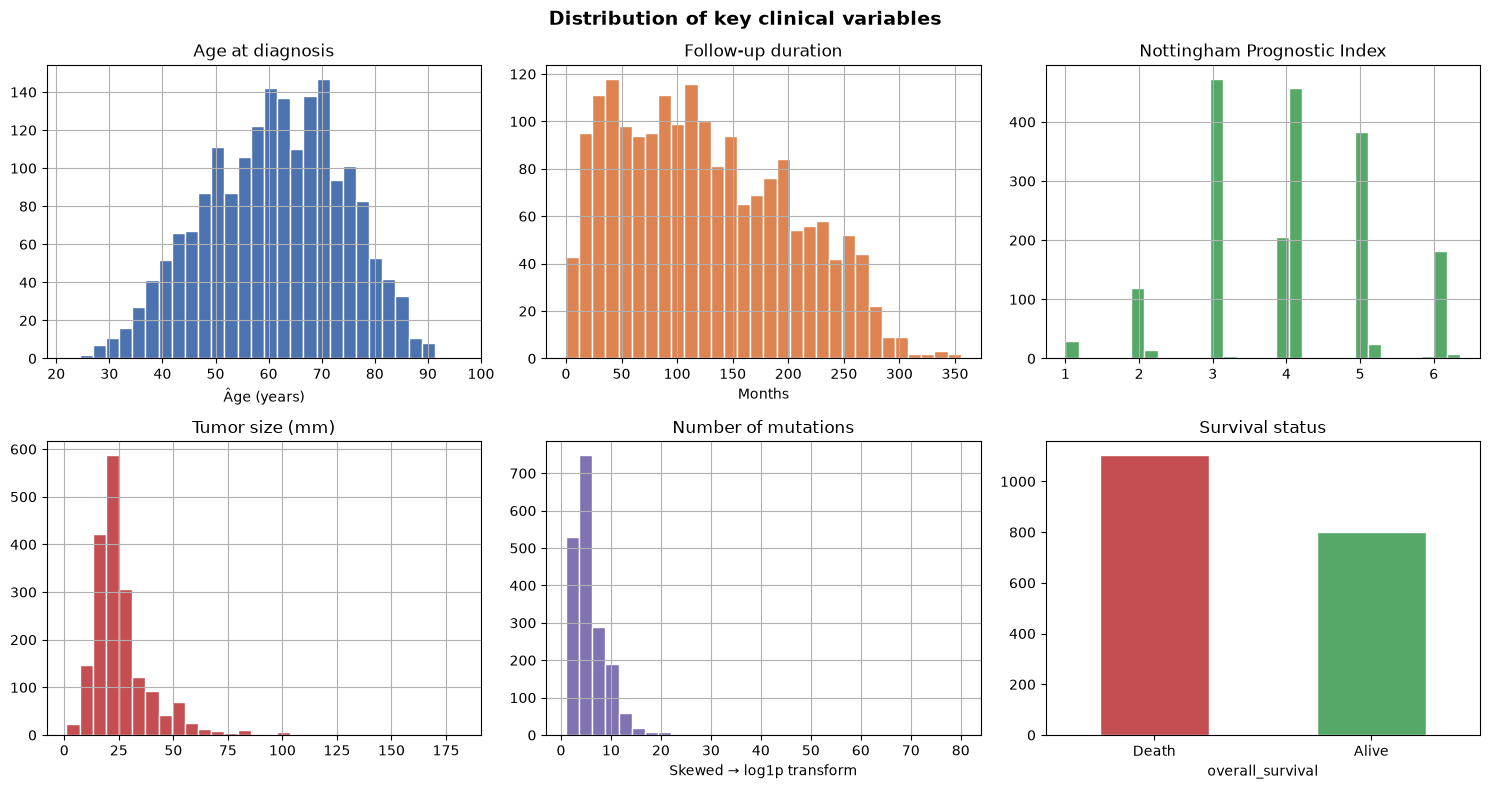

In [56]:
os.makedirs("../outputs/figures", exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Distribution of key clinical variables", fontsize=14, fontweight="bold")

df["age_at_diagnosis"].hist(bins=30, ax=axes[0,0], color="#4C72B0", edgecolor="white")
axes[0,0].set_title("Age at diagnosis") ; axes[0,0].set_xlabel("Âge (years)")

df["overall_survival_months"].hist(bins=30, ax=axes[0,1], color="#DD8452", edgecolor="white")
axes[0,1].set_title("Follow-up duration") ; axes[0,1].set_xlabel("Months")

df["nottingham_prognostic_index"].hist(bins=30, ax=axes[0,2], color="#55A868", edgecolor="white")
axes[0,2].set_title("Nottingham Prognostic Index")

df["tumor_size"].hist(bins=30, ax=axes[1,0], color="#C44E52", edgecolor="white")
axes[1,0].set_title("Tumor size (mm)")

df["mutation_count"].hist(bins=30, ax=axes[1,1], color="#8172B2", edgecolor="white")
axes[1,1].set_title("Number of mutations")
axes[1,1].set_xlabel("Skewed → log1p transform")

df["overall_survival"].map({0: "Death", 1: "Alive"}).value_counts().plot(
    kind="bar", ax=axes[1,2], color=["#C44E52", "#55A868"], edgecolor="white")
axes[1,2].set_title("Survival status")
axes[1,2].set_xticklabels(["Death", "Alive"], rotation=0)

plt.tight_layout()
plt.savefig("../outputs/figures/01_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

> - **Age**: near-normal distribution, centered around 61 years: middle-aged cohort
> - **Follow-up duration**: spread-out distribution with a long right tail: highly variable follow-up across patients
> - **NPI**: slightly left-skewed distribution, centered around 4: majority of intermediate cases
> - **Tumor size**: right tail with a few extreme values (the 3 cases > 150mm are visible)
> - **Mutation count**: strong right skew (long tail) → **log1p transform necessary** before ML
> - **Survival status**: moderate imbalance (58% death / 42% alive) → acceptable for modeling

### Biomarkers ER / PR / HER2

Hormone receptors (ER, PR) and HER2 are the central prognostic and predictive biomarkers for breast cancer. Their distribution will determine the subgroups for KM curves.

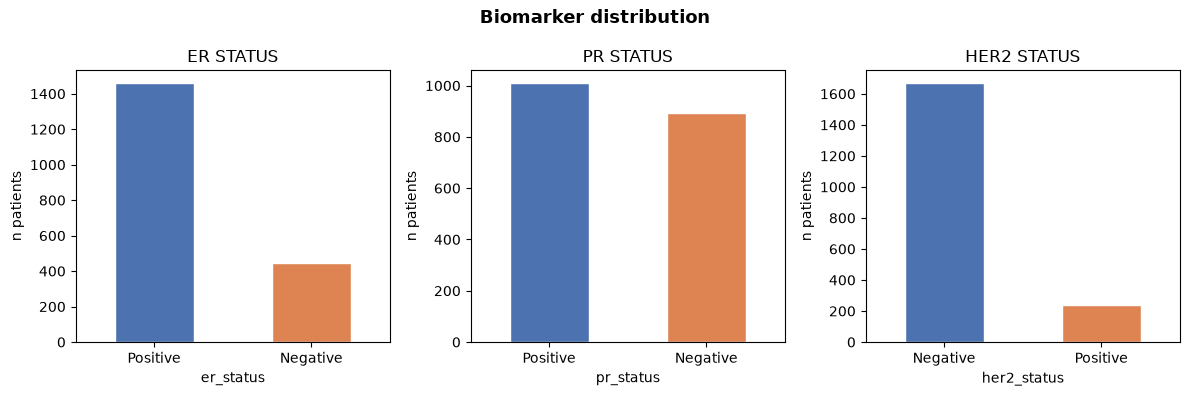

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Biomarker distribution", fontsize=13, fontweight="bold")

for ax, col in zip(axes, ["er_status", "pr_status", "her2_status"]):
    df[col].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"], edgecolor="white")
    ax.set_title(col.replace("_", " ").upper())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_ylabel("n patients")

plt.tight_layout()
plt.savefig("../outputs/figures/01_biomarqueurs.png", dpi=150, bbox_inches="tight")
plt.show()

> - **ER+ majority**: consistent with breast cancer epidemiology (~70-75% ER+ in the general population)
> - **PR** follows ER with a slightly lower positive rate: biologically expected (PR depends on ER signaling)
> - **HER2**: predominantly negative (~80%): consistent with HER2+ prevalence (~15-20% in the population)
> - These distributions will allow for ER+/ER- and HER2+/HER2- KM curves with sufficient sample sizes in each group ✅

### Treatments

We visualize the rate of use for each treatment. Highly imbalanced groups (e.g., 90% treated) would make KM comparisons unreliable due to a lack of statistical power in the minority group.

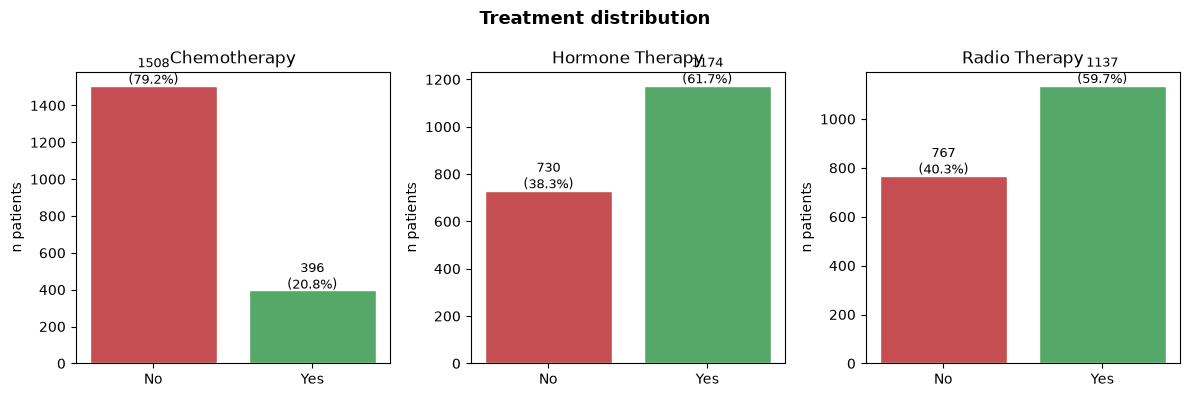

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Treatment distribution", fontsize=13, fontweight="bold")

for ax, col in zip(axes, treatment_cols):
    counts = df[col].value_counts().sort_index()
    ax.bar(["No", "Yes"], counts.values, color=["#C44E52", "#55A868"], edgecolor="white")
    ax.set_title(col.replace("_", " ").title())
    ax.set_ylabel("n patients")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 10, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/01_traitements.png", dpi=150, bbox_inches="tight")
plt.show()

> The three treatments have sufficiently balanced groups to allow robust KM comparisons. Hormone therapy is the most frequent treatment, consistent with the ER+ majority of the cohort: ER+ patients are eligible for hormone therapy.

### Tumor Stage Distribution

Even though `tumor_stage` is excluded from models (MNAR + imbalance), its distribution is informative for characterizing the cohort's population.

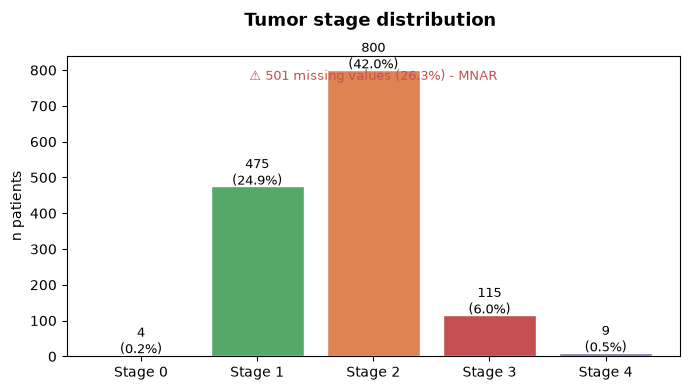

In [63]:
fig, ax = plt.subplots(figsize=(7, 4))

stage_counts = df["tumor_stage"].value_counts().sort_index()
bars = ax.bar(
    ["Stage 0", "Stage 1", "Stage 2", "Stage 3", "Stage 4"],
    stage_counts.values,
    color=["#4C72B0", "#55A868", "#DD8452", "#C44E52", "#8172B2"],
    edgecolor="white"
)
ax.set_title("Tumor stage distribution \n", fontsize=13, fontweight="bold")
ax.set_ylabel("n patients")

for bar, v in zip(bars, stage_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 5,
            f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=9)

ax.annotate(f"⚠️ {df['tumor_stage'].isnull().sum()} missing values (26.3%) - MNAR",
            xy=(0.5, 0.92), xycoords="axes fraction", ha="center",
            fontsize=9, color="#C44E52")

plt.tight_layout()
plt.savefig("../outputs/figures/01_stades.png", dpi=150, bbox_inches="tight")
plt.show()

> - **Stage 0**: n=4 → anecdotal
> - **Stage 1**: n=475 → well represented
> - **Stage 2**: n=800 → majority → early to intermediate diagnosis cohort
> - **Stage 3**: n=115 → poorly represented
> - **Stage 4**: n=9 → almost absent → explains the slight NPI drop at stage 4 observed in section 4
>
> Total with known stage: 1,403 / 1,904 → confirms the 26.3% missing rate
> Double issue: **MNAR missingness (26%) + severe class imbalance**
> → **Conclusion: `tumor_stage` unusable in models**, NPI retained as a proxy

## 6. Summary & Decisions for Preprocessing

| Observation | Implication |
|---|---|
| 1904 patients, 693 variables (including ~660 genomic) | Feature selection essential before ML |
| `overall_survival` reverse encoded (0=death) | Create `event = 1 - overall_survival` for lifelines |
| 57.9% deaths, median follow-up 9.6 years | Mature cohort, stable KM and Cox |
| `tumor_stage`: 26.3% missing, MNAR + imbalance | Exclude from models, use NPI as proxy |
| `mutation_count` highly skewed (max=80) | Log1p transform before ML |
| 3 tumors > 150mm including 1 incoherent (stage 1) | Keep, monitor influence on models |
| ER+ majority (~75%), HER2- majority (~80%) | Well-populated KM subgroups |
| Near-balanced classes (58/42) | `class_weight='balanced'` useful but not critical |

**Next Steps**:
- `02_preprocessing.ipynb`: imputation, encoding, log1p-transform, feature selection
- `03_kaplan_meier.ipynb`: KM curves by ER status, HER2, grade, treatment
- `04_cox_model.ipynb`: Univariate → multivariate Cox
- `05_ml_prediction.ipynb`: 5-year survival prediction (Random Forest + XGBoost)